In [6]:
from count_min_sketch import CountMinSketch
from typing import Tuple
import numpy as np
from infinite_str_stream_generation import infinite_str_stream_generation, get_set_of_unique_elements
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
def calculate_cms_error(n: int, eps: float, delta: float, num_trials: int = 5):
    abs_errors = []
    rel_errors = []

    for _ in range(num_trials):
        sketch = CountMinSketch.make_sketch_with_accuracy(eps=eps, delta=delta)

        true_counts = {}
        stream = get_set_of_unique_elements(n)
        for element in stream:
            true_counts[element] = true_counts.get(element, 0) + 1

        for element in stream:
            sketch.add(element)

        trial_rel = []
        for element, real_count in true_counts.items():
            estimated = sketch.estimate(element)
            error = estimated - real_count

            trial_rel.append(error / real_count if real_count > 0 else 0)

        rel_errors.append(np.mean(trial_rel))

    return np.mean(rel_errors), np.var(rel_errors), sketch.w, sketch.d


In [8]:
n_values = (25000, 250000, 10**6)

eps_values = (0.7, 0.15, 0.05)

results_of_experiments = []

for n in n_values:
    for eps in eps_values:
        mean, var, w, d = calculate_cms_error(n=n, eps=eps, num_trials=3, delta=eps)

        theoretical_std_err = eps * n

        results_of_experiments.append({
            "n": n,
            "w": w, "d": d,
            "eps": eps,
            "delta": eps,
            "theory_value": theoretical_std_err,
            "mean": mean,
            "per_mean": mean*100,
            "var": var,
            "per_var": var * 100
        })

results_of_experiments_df = pd.DataFrame(results_of_experiments)

In [14]:
results_of_experiments_df

,n,w,d,eps,delta,theory_value,mean,per_mean,var,per_var
0,25000,4,1,0.70,0.70,17500.0,6250.199715,6.250200e+05,3.722030,372.203040
1,25000,19,2,0.15,0.15,3750.0,1275.508720,1.275509e+05,5.929786,592.978555
2,25000,55,3,0.05,0.05,1250.0,422.734388,4.227344e+04,0.654275,65.427544
3,250000,4,1,0.70,0.70,175000.0,62500.072572,6.250007e+06,6.437799,643.779935
4,250000,19,2,0.15,0.15,37500.0,12809.277555,1.280928e+06,14.164073,1416.407314
5,250000,55,3,0.05,0.05,12500.0,4289.378698,4.289379e+05,35.916810,3591.681013
6,1000000,4,1,0.70,0.70,700000.0,249999.324983,2.499993e+07,10.737280,1073.728001
7,1000000,19,2,0.15,0.15,150000.0,51274.338918,5.127434e+06,0.003538,0.353789
8,1000000,55,3,0.05,0.05,50000.0,17163.558687,1.716356e+06,50.469979,5046.997858


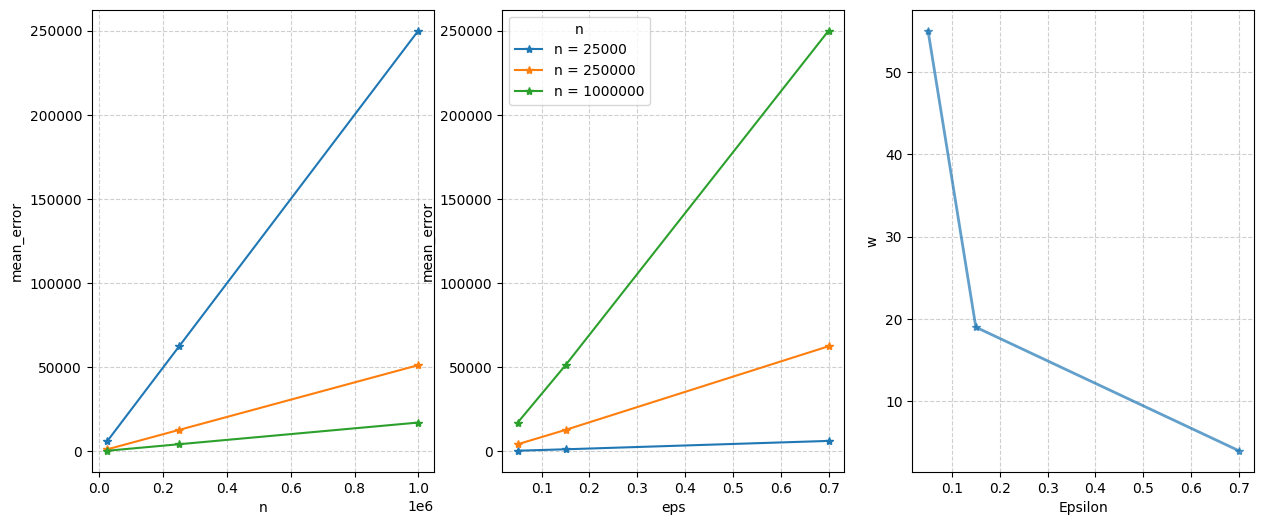

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(15, 6))

for eps in eps_values:
    subset = results_of_experiments_df[results_of_experiments_df['eps'] == eps]
    ax[0].plot(subset['n'], subset['mean'], marker='*', label=f'eps = {eps}')

ax[0].set_xlabel('n')
ax[0].set_ylabel('mean_error')

ax[0].grid(True, linestyle='--', alpha=0.6)

for n in n_values:
    subset = results_of_experiments_df[results_of_experiments_df['n'] == n]
    ax[1].plot(subset['eps'], subset['mean'], marker='*', label=f'n = {n}')

ax[1].set_xlabel('eps')
ax[1].set_ylabel('mean_error')

ax[1].legend(title="n")
ax[1].grid(True, linestyle='--', alpha=0.6)

subset_n = results_of_experiments_df[results_of_experiments_df['n'] == n_values[0]]
ax[2].plot(subset_n['eps'], subset_n['w'],
                marker='*', lw=2, alpha=0.7)


ax[2].set_xlabel('Epsilon')
ax[2].set_ylabel('w')
ax[2].grid(True, linestyle='--', alpha=0.6)


plt.show()